# Practica04: Analisis de Datos Exploratorios con Python y Jupyter Notebook en un Dataset de Productos de Amazon Store

**Programa de Estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analitica de Datos para Negocios Digitales \
**Docente:** M.T.I. Marco A. Ramirez Hernandez \
**Periodo:** Mayo - Agosto 2026 

### Unidad 2: Preparacion de los Datos

**Nombre del Estudiante:** Luis Dario Mendoza Morales \
**Matricula:** 230639 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px; font-family: Arial, sans-serif;">
    <h1 style="color: #FFFFFF; font-size: 2.2em; margin: 0; font-weight: bold; text-shadow: 2px 2px 4px rgba(0,0,0,0.4);">
        Prediccion de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)
    </h1>
    <p style="color: #FFD700; font-size: 1.2em; margin-top: 15px; font-weight: 500; letter-spacing: 0.5px;">
        Predicción de Precios • Análisis de Categorías • Ingeniería de Funcionalidades • Comparación de Modelos
    </p>
</div>

## Tabla de Contenido
| # | Seccion | Descripcion |
|---|---|---|
| 1 | [Instalaciones y Carga de Datos](#s1) | Librerias, carga del CSV, primeros comandos de estructura |
| 2 | [Diccionario de los Datos del DataFrame](#s2) | Explicacion del contenido de columnas y calcular el % de datos faltantes |

## 1. Instalaciones & Carga de Datos <a id='s1'></a>

<div style="background:#f0f8ff; padding: 12px; border-left: 4px solid #FF9900; border-radius:5px00; color: #0066cc;">
<b>Dataset:</b> Amazon India Listas de Prductos 1,436 productos entre Libros, Kindle, Deportes & más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoria, longitud del nombre, y diponibilidad<br>
<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

print(f'👌 Pandas  : {pd.__version__}')
print(f'👌 NumPy   : {np.__version__}')
print('👌 Todas las librerias cargaron con exito!')

👌 Pandas  : 2.3.3
👌 NumPy   : 2.3.5
👌 Todas las librerias cargaron con exito!


In [7]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print(f'📦 Shape    : {df_raw.shape}')
print(f'📋 Columns  : {df_raw.columns.tolist()}')
df_raw.head(3)

📦 Shape    : (1445, 17)
📋 Columns  : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \n Fedor G. Pikus (Au...,NaN,"""https://images-na.ssl-images-amazon.com/imag...",https://images-na.ssl-images-amazon.com/image...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \nErnest Lynn \n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure,NaN
https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \nNinety Nine Cents Pres...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ...",NaN


## 2. Diccionario de los Datos del DataFrame <a id='s2'></a>

In [8]:
col_info = {
'rl': 'URL del Producto en Amazon.in',
'asin': 'Número Estandarizado de Identificación por Amazon (ID único)',
'name': 'Nombre o Título del Producto',
'overview': 'Breve Reseña del Producto (mayoría vacío [])',
'price': 'Precio como string (ej. "1,600.00")',
'currency': 'Código de Divisa (todas en INR)',
'availability': 'Texto del Estado del Stock (Inventario)',
'brand': 'Nombre de la Marca/Autor',
'about_item': 'Detalles/Especificaciones (mayoría faltante)',
'img_source': 'URLs de Imágenes del Producto',
'description': 'Descripción detallada y completa (mayoría faltante)',
'specifications': 'Especificaciones Técnicas',
'primary_category': 'Categoria Principal',
'category_1': 'Subcategoría de nivel 1',
'category_2': 'Subcategoría de nivel 2',
'category_3': 'Subcategoria de nivel 3',
'breadcrumbs': 'Ruta de Categorías'
}

print('📖Diccionario por columnas:')

for col, desc in col_info.items():
 missing_pct = df_raw[col].isnull().mean() * 100
 print(
     f'{col:20s} | '
     f'{desc[:45]:45s} | '
     f'Missing: {missing_pct:.0f}%'
)

📖Diccionario por columnas:
rl                   | URL del Producto en Amazon.in                 | Missing: 0%
asin                 | Número Estandarizado de Identificación por Am | Missing: 0%
name                 | Nombre o Título del Producto                  | Missing: 0%
overview             | Breve Reseña del Producto (mayoría vacío [])  | Missing: 24%
price                | Precio como string (ej. "1,600.00")           | Missing: 24%
currency             | Código de Divisa (todas en INR)               | Missing: 33%
availability         | Texto del Estado del Stock (Inventario)       | Missing: 1%
brand                | Nombre de la Marca/Autor                      | Missing: 92%
about_item           | Detalles/Especificaciones (mayoría faltante)  | Missing: 0%
img_source           | URLs de Imágenes del Producto                 | Missing: 92%
description          | Descripción detallada y completa (mayoría fal | Missing: 2%
specifications       | Especificaciones Técnicas       

## 3. limpieza de Datos <a id='s3'></a>

<div style="background:#fff8e1; padding: 12px; border-left: 4px solid #FF9900; border-radius: 5px; color: #0066cc;">
<b> Pasos clave para la limpieza:</b><br>
Pareseas el precio strings como "1,600.00" float 1600.0<br>
Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
Estandarizar el texto de disponibilidad en categorías limpias<br>
Eliminar duplicados
</div>

In [9]:
df = df_raw.copy()

# Parse price
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# Standardise availability 
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# Text length features 
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

#  Duplicate check 
dupes = df.duplicated(subset='asin').sum()
print(f'--- Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'--- Duplicate ASINs: {dupes}')
print(f'--- Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

--- Price parsed: 0 / 1,445 products
--- Duplicate ASINs: 6
--- Availability categories: {'Other': 1435, 'Unknown': 10}


,name,price_clean,avail_clean,primary_category,name_length
https://www.amazon.in/dp/1788832566,[],NaN,Other,Books,2
https://www.amazon.in/dp/0766199592,[],NaN,Other,Action & Adventure,2
https://www.amazon.in/dp/B071ZCD9XH,[],NaN,Other,Kindle eBooks,2
https://www.amazon.in/dp/B00IG6EML8,[],NaN,Other,Kindle eBooks,2
https://www.amazon.in/dp/1637583060,[],NaN,Other,"Crime, Thriller & Mystery",2


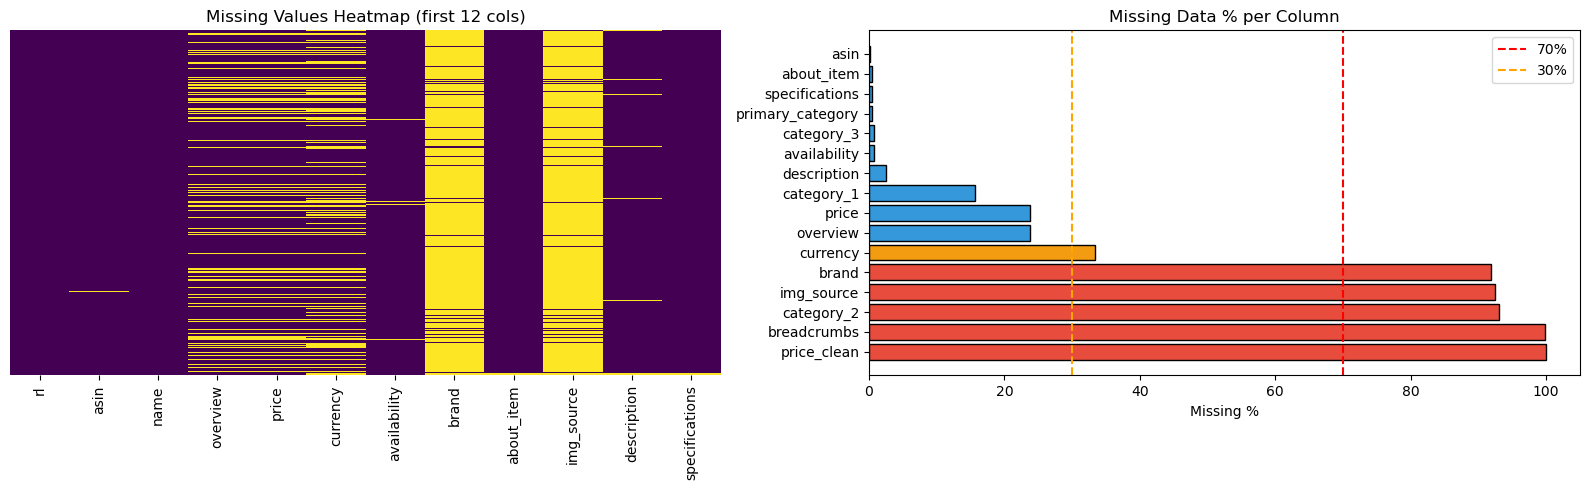

                  Missing Count  Missing Pct
price_clean                1445        100.0
breadcrumbs                1444         99.9
category_2                 1345         93.1
img_source                 1336         92.5
brand                      1326         91.8
currency                    483         33.4
overview                    344         23.8
price                       344         23.8
category_1                  227         15.7
description                  36          2.5
availability                 10          0.7
category_3                   10          0.7
primary_category              6          0.4
specifications                6          0.4
about_item                    6          0.4
asin                          1          0.1


In [10]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[df.columns[:12]].isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap (first 12 cols)')


mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]

axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')
axes[1].set_xlabel('Missing %'); axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout(); plt.show()
print(missing[missing['Missing Count'] > 0].to_string())